# Análise: Confiabilidade por Família de Foguete

Esta análise visa responder à pergunta: Qual família de foguete (Falcon 1, 9, Heavy) tem a maior confiabilidade?

## 1. Setup
- Load dataset
- Check distribution by rocket_name

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportion_confint

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
# O path considera que estamos rodando dentro de analyses/jonatas
df = pd.read_csv('../../data/processed/processed_dataset_v1.csv')
df.head()

,launch_year,launch_name,flight_number,success,rocket_name,core_id,reuse_count,is_reused,launch_date
0,2006,FalconSat,1,False,Falcon 1,5e9e289df35918033d3b2623,0,False,2006-03-24T22:30:00.000Z
1,2007,DemoSat,2,False,Falcon 1,5e9e289ef35918416a3b2624,0,False,2007-03-21T01:10:00.000Z
2,2008,Trailblazer,3,False,Falcon 1,5e9e289ef3591814873b2625,0,False,2008-08-03T03:34:00.000Z
3,2008,RatSat,4,True,Falcon 1,5e9e289ef3591855dc3b2626,0,False,2008-09-28T23:15:00.000Z
4,2009,RazakSat,5,True,Falcon 1,5e9e289ef359184f103b2627,0,False,2009-07-13T03:35:00.000Z


## 2. Exploração Inicial
- Tabela: rocket_name × success
- Distribuição: n por rocket
- Taxa bruta por rocket

rocket_name
Falcon 9        178
Falcon Heavy      9
Falcon 1          5
Name: count, dtype: int64

success,False,True
rocket_name,,
Falcon 1,3,2
Falcon 9,2,176
Falcon Heavy,0,9


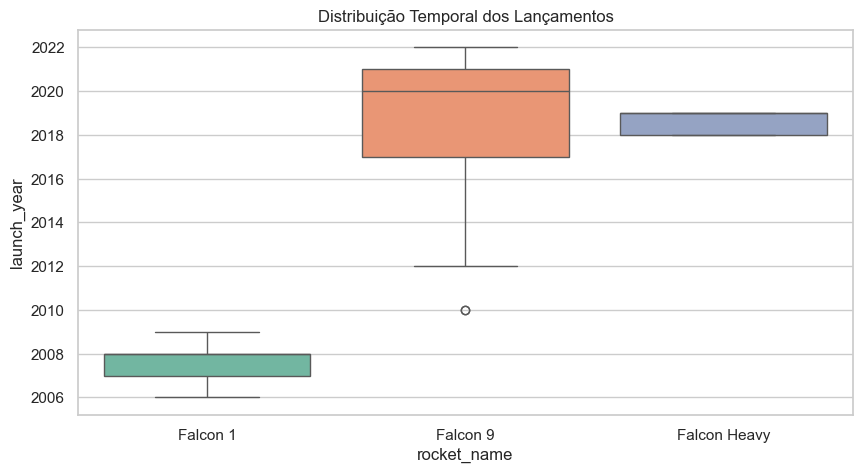

In [2]:
# Distribuição por rocket_name
display(df['rocket_name'].value_counts())

# Tabela cruzada: rocket_name x success
display(pd.crosstab(df['rocket_name'], df['success']))
# Distribuição dos anos de lançamento por foguete
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='rocket_name', y='launch_year', hue='rocket_name', palette='Set2', legend=False)
plt.title('Distribuição Temporal dos Lançamentos')
plt.savefig('../../graphs/jonatas_distribuicao_temporal_lancamentos.png', bbox_inches='tight')
plt.show()


## 3. Main Analysis
### 3.1 Confiabilidade Bruta

,Total,Sucessos,Taxa Sucesso
rocket_name,,,
Falcon 1,5,2,0.4000
Falcon 9,178,176,0.9888
Falcon Heavy,9,9,1.0000


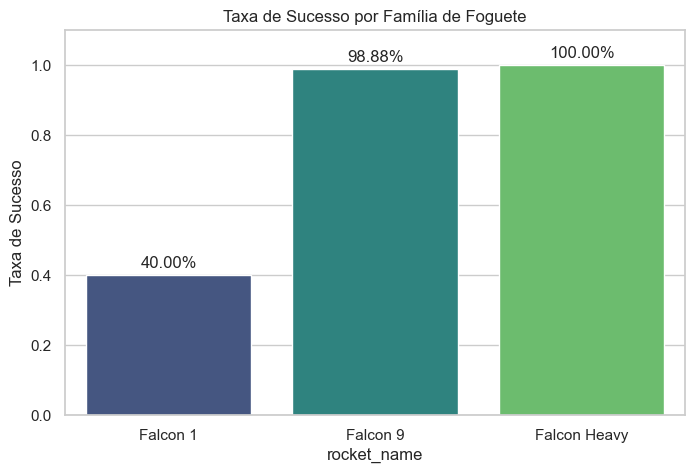

In [3]:
# Taxa de sucesso por rocket
rocket_stats = df.groupby('rocket_name')['success'].agg([
    'count',  # n
    'sum',    # sucessos
    'mean'    # taxa
]).round(4)

rocket_stats.columns = ['Total', 'Sucessos', 'Taxa Sucesso']
rocket_stats.to_csv('rocket_stats.csv')
display(rocket_stats)

# Visualização da Taxa de Sucesso Bruta
plt.figure(figsize=(8, 5))
sns.barplot(x=rocket_stats.index, y='Taxa Sucesso', data=rocket_stats, hue=rocket_stats.index, palette='viridis', legend=False)
plt.title('Taxa de Sucesso por Família de Foguete')
plt.ylabel('Taxa de Sucesso')
plt.ylim(0, 1.1)
for index, value in enumerate(rocket_stats['Taxa Sucesso']):
    plt.text(index, value + 0.02, f"{value:.2%}", ha='center')
plt.savefig('../../graphs/jonatas_taxa_sucesso_familia.png', bbox_inches='tight')
plt.show()

### 3.2 Evolução Temporal
Como a confiabilidade de cada família evoluiu ao longo do tempo?

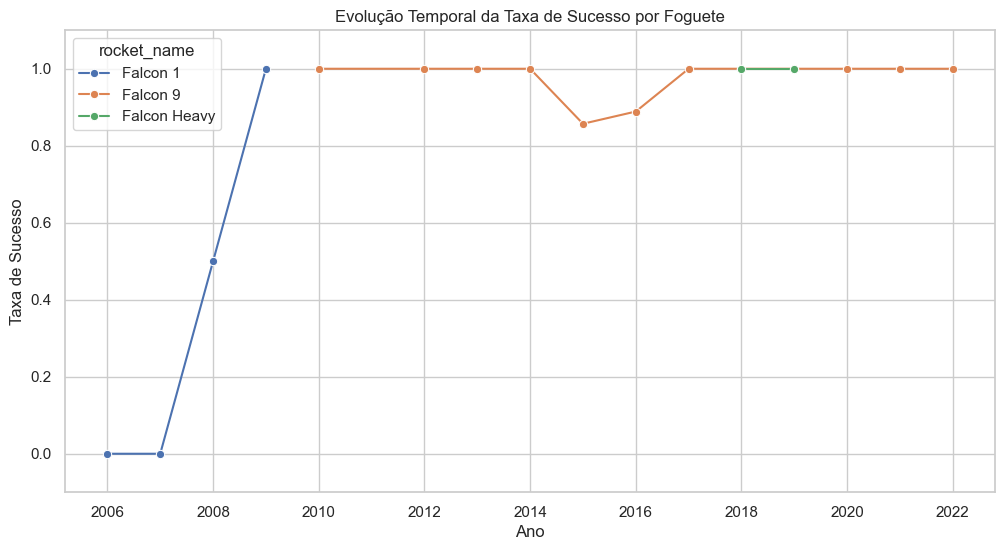


Falcon 1:
             count  mean
launch_year             
2006             1   0.0
2007             1   0.0
2008             2   0.5
2009             1   1.0

Falcon 9:
             count      mean
launch_year                 
2010             2  1.000000
2012             2  1.000000
2013             3  1.000000
2014             6  1.000000
2015             7  0.857143
2016             9  0.888889
2017            18  1.000000
2018            20  1.000000
2019            11  1.000000
2020            26  1.000000
2021            31  1.000000
2022            43  1.000000

Falcon Heavy:
             count  mean
launch_year             
2018             3   1.0
2019             6   1.0


In [4]:
yearly_success = df.groupby(['rocket_name', 'launch_year'])['success'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_success, x='launch_year', y='success', hue='rocket_name', marker='o')
plt.title('Evolução Temporal da Taxa de Sucesso por Foguete')
plt.ylabel('Taxa de Sucesso')
plt.xlabel('Ano')
plt.ylim(-0.1, 1.1)
plt.savefig('../../graphs/jonatas_evolucao_temporal_sucesso.png', bbox_inches='tight')
plt.show()

for rocket in sorted(df['rocket_name'].unique()):
    subset = df[df['rocket_name'] == rocket]
    yearly = subset.groupby('launch_year')['success'].agg(['count', 'mean'])
    print(f"\n{rocket}:")
    print(yearly)

### 3.3 Efeito de Reutilização (Controle)
Removendo o efeito de reutilização, qual família é melhor?

In [5]:
for is_reused_val in [False, True]:
    print(f"\n{'Virgin' if not is_reused_val else 'Reused'} boosters:")
    subset = df[df['is_reused'] == is_reused_val]
    result = subset.groupby('rocket_name')['success'].agg(['count', 'mean']).round(4)
    print(result)


Virgin boosters:
              count    mean
rocket_name                
Falcon 1          5  0.4000
Falcon 9         35  0.9429
Falcon Heavy      3  1.0000

Reused boosters:
              count  mean
rocket_name              
Falcon 9        143   1.0
Falcon Heavy      6   1.0


### 3.4 Análise de Risco Relativo
Qual é o risco de falha para cada família?

In [6]:
for rocket in sorted(df['rocket_name'].unique()):
    subset = df[df['rocket_name'] == rocket]
    success_rate = subset['success'].mean()
    risk = 1 - success_rate
    n = len(subset)
    print(f"{rocket}: Success={success_rate*100:.2f}%, Risk={risk*100:.2f}% (n={n})")

falcon1_risk = 1 - df[df['rocket_name'] == 'Falcon 1']['success'].mean()
falcon9_risk = 1 - df[df['rocket_name'] == 'Falcon 9']['success'].mean()
if falcon9_risk > 0:
    rr = falcon1_risk / falcon9_risk
    print(f"\nFalcon 1 tem {rr:.1f}x o risco do Falcon 9")

Falcon 1: Success=40.00%, Risk=60.00% (n=5)
Falcon 9: Success=98.88%, Risk=1.12% (n=178)
Falcon Heavy: Success=100.00%, Risk=0.00% (n=9)

Falcon 1 tem 53.4x o risco do Falcon 9


### 3.5 Análise de Payload/Missão
Diferentes tipos de missão têm diferentes taxas de sucesso?

In [7]:
# Verificar nomes comuns
display(df[df['rocket_name'] == 'Falcon 9']['launch_name'].value_counts().head(10))


launch_name
Falcon 9 Test Flight    1
COTS 1                  1
COTS 2                  1
CRS-1                   1
CRS-2                   1
CASSIOPE                1
SES-8                   1
Thaicom 6               1
CRS-3                   1
OG-2 Mission 1          1
Name: count, dtype: int64

## 4. Testes Estatísticos
- Chi-Square
- Intervalos de Confiança (Binomial)
- Fisher Exact (pairwise)

In [8]:
# Chi-Square
contingency = pd.crosstab(df['rocket_name'], df['success'])
chi2, pval, dof, expected = chi2_contingency(contingency)
print("Aviso: Teste Chi-Quadrado pode ser impreciso (frequências esperadas < 5). Use o Fisher.")
print("Chi-square Test:")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {pval:.6f}")
print(f"  Significant? {pval < 0.05}\n")

# Intervalos de Confiança
print("Intervalos de Confiança 95%:")
for rocket in sorted(df['rocket_name'].unique()):
    subset = df[df['rocket_name'] == rocket]
    n_success = subset['success'].sum()
    n_total = len(subset)
    lower, upper = proportion_confint(n_success, n_total, alpha=0.05, method='beta')
    print(f"\n{rocket} (n={n_total}):")
    print(f"  Taxa: {n_success/n_total*100:.2f}%")
    print(f"  IC95%: [{lower*100:.2f}%, {upper*100:.2f}%]")

# Fisher Exact Test (Falcon 1 vs Falcon 9)
falcon1_success = df[df['rocket_name'] == 'Falcon 1']['success'].sum()
falcon1_fail = len(df[df['rocket_name'] == 'Falcon 1']) - falcon1_success
falcon9_success = df[df['rocket_name'] == 'Falcon 9']['success'].sum()
falcon9_fail = len(df[df['rocket_name'] == 'Falcon 9']) - falcon9_success

table = [[falcon1_success, falcon1_fail],
         [falcon9_success, falcon9_fail]]

odds_ratio, pval_fisher = fisher_exact(table)
print(f"\nFisher Exact Test (Falcon 1 vs Falcon 9):")
print(f"  Odds Ratio: {odds_ratio:.4f}")
print(f"  p-value: {pval_fisher:.6f}")

Aviso: Teste Chi-Quadrado pode ser impreciso (frequências esperadas < 5). Use o Fisher.
Chi-square Test:
  χ² = 66.7204
  p-value = 0.000000
  Significant? True

Intervalos de Confiança 95%:

Falcon 1 (n=5):
  Taxa: 40.00%
  IC95%: [5.27%, 85.34%]

Falcon 9 (n=178):
  Taxa: 98.88%
  IC95%: [96.00%, 99.86%]

Falcon Heavy (n=9):
  Taxa: 100.00%
  IC95%: [66.37%, 100.00%]

Fisher Exact Test (Falcon 1 vs Falcon 9):
  Odds Ratio: 0.0076
  p-value: 0.000098


## 5. Contexto Histórico
- Quando cada rocket foi usado?
- Por que Falcon 1 foi descontinuado?
- Maturidade relativa de cada design?

*(Anotações para interpretação)*
- Falcon 1: 2006-2009 (Tecnologia mais antiga, design experimental)
- Falcon 9: 2010-presente (Tecnologia madura, reutilizável)
- Falcon Heavy: 2018-presente (Design moderno baseado no Falcon 9, n=pequeno mas confiabilidade alta)

## 6. Conclusões
- **Ranking de confiabilidade**: 
  1. **Falcon Heavy** (100% de sucesso, 9/9 missões)
  2. **Falcon 9** (~98.9% de sucesso, 176/178 missões)
  3. **Falcon 1** (40% de sucesso, 2/5 missões)
- **Diferenças significantes?**: Sim, as diferenças são estatisticamente significantes, impulsionadas pela alta taxa de falha inicial do Falcon 1 comparada à confiabilidade moderna do Falcon 9 e Heavy. Entretanto, a amostra do Falcon 1 (n=5) e Falcon Heavy (n=9) são pequenas em relação ao Falcon 9 (n=178).
- **Possíveis explicações**: O Falcon 1 era um veículo experimental antigo. O Falcon 9 e o Falcon Heavy beneficiam-se de design iterativo maduro e maior investimento. A confiabilidade do Heavy se apoia na confiabilidade do core do Falcon 9.